**Week 3 – Classification**

The main objective of this project is to build a supervised machine learning classification model using the MNIST dataset to identify handwritten digits. Specifically, the task has been simplified into a binary classification problem to determine whether a given image represents the digit “5” or not. The project focuses not only on model training but also on evaluating model performance using appropriate metrics such as precision, recall, F1-score, and confusion matrix, especially in the presence of class imbalance.

In [5]:
from sklearn.datasets import fetch_openml
import numpy as np

# Load the MNIST dataset from OpenML (online database)
mnist = fetch_openml('mnist_784', version=1, cache=True)

# NOTE:
# The data is NOT a local file
# It is automatically downloaded from OpenML and cached locally

# Convert target labels from string to integer (important for ML models)
mnist.target = mnist.target.astype(np.int8)

# Separate features and labels
X = mnist["data"]
y = mnist["target"]

# Check basic structure
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (70000, 784)
Target shape: (70000,)


This code loads the MNIST dataset from OpenML, an online data repository, meaning the dataset is not stored locally but is automatically downloaded and cached. After loading, the target labels are converted from strings to integers using astype(np.int8) to ensure compatibility with machine learning models. The dataset is then separated into features (X) and labels (y), and the structure is verified using shape attributes.

The MNIST database of handwritten digits, available from this page, has a training set of 60,000 examples, and a test set of 10,000 examples. It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image.

Learn more about the dataset [here](http://yann.lecun.com/exdb/mnist/).

<img src = "https://drive.google.com/uc?id=100v43llJaBhmDze48CCTwBeZj3HCRI-J" alt="OpenML" height="420" width="720" align="middle">

Learn more about [OpenML](https://www.openml.org/).


# What type of data object is MNIST?

The function type(mnist) is used to identify the data type of the dataset object. It returns that MNIST is a Bunch object, which is a data structure used in Scikit-learn to store datasets. This object behaves like both a dictionary and an object, allowing access to its elements such as data and target. Understanding the data type helps determine how to manipulate and extract information from the dataset correctly.

# Setup

First import a few common modules, ensure MatplotLib plots figures inline

In [1]:
# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

<font size="8" color="green">What type of data object is MNIST?</font>


In [6]:
# How do you know? What funtion/method would tell us the type of an object? Try describe, show, try, learn, type and see which one works!
type(mnist)

sklearn.utils._bunch.Bunch

## What is MNIST data shape/dimension?

The MNIST dataset has a shape of (70,000, 784), where 70,000 represents the total number of samples (images), and 784 represents the number of features per image. Each image is originally 28 × 28 pixels, which is flattened into a one-dimensional vector of 784 values. The target variable has a shape of (70,000,), representing the digit label (0–9) for each image.

This is called a high-dimensional dataset
- Each pixel = a feature
- Total features = 784 → relatively large for basic models

Explanation :

- 70,000 rows Each row = one image (one handwritten digit)
- 784 columns Each image is originally: ( 28x28 = 784 )
- 28 pixels (height)
- 28 pixels (width) Flattened into a 1D vector of 784 features



In [6]:
#mnist.data is a numpy array
print(type(mnist.data))

#use shape to see shape of a numpy array
mnist.data.shape

<class 'pandas.core.frame.DataFrame'>


(70000, 784)

In [7]:
X, y = mnist["data"], mnist["target"]
X.shape

(70000, 784)

In [10]:
y.shape

(70000,)

In [11]:
28*28

784

## Lets take a look at example of handwritings!

In [7]:
# Define a function to plot image
def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = mpl.cm.binary,#mlp (matplotlib)
               interpolation="nearest")
    plt.axis("off")

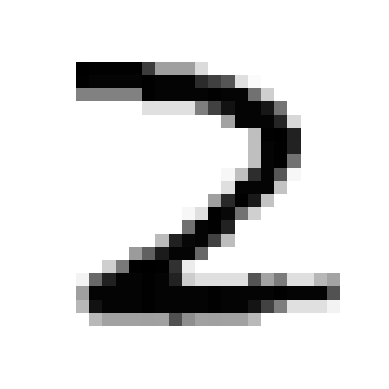

In [8]:
some_digit = X.iloc[7655-1].values # Index can be between 0 to 69999!
plot_digit(some_digit)

<font size="8" color="green">Can you plot handwriting digit in X[45]? </font>

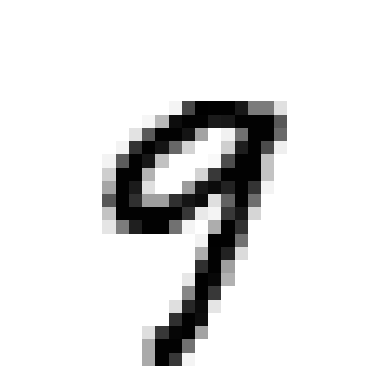

In [9]:
plot_digit(X.iloc[45].values)

# Lets see content of target variable

In [10]:
y[7655-1]

np.int8(2)

# Split dataset to train and test

In [11]:
# Write a code to split your dataset into 80/20 dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.2)


<font size="8" color="green">Can you verify data dimension?</font>

In [12]:
# print shape of the data to ensure your split is right
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((56000, 784), (14000, 784), (56000,), (14000,))

# Binary classifier

###Predict if an image is 5 or not.

In [13]:
# if y_train value equals 5, it replaces it with true otherwise false
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

In [14]:
y_train_5.shape

(56000,)

**Note**: a few hyperparameters will have a different default value in future versions of Scikit-Learn, so a warning is issued if you do not set them explicitly. This is why we set `max_iter=5` and `tol=-np.infty`, to get the same results as in the book, while avoiding the warnings.

In [15]:
from sklearn.linear_model import SGDClassifier

#sgd stands for stochastic gradient descent (read more about GSD https://medium.com/@lachlanmiller_52885/machine-learning-week-1-cost-function-gradient-descent-and-univariate-linear-regression-8f5fe69815fd)
#clf stands for classifier
sgd_clf = SGDClassifier(max_iter=5, tol=0.00001, random_state=42)
sgd_clf.fit(X_train, y_train_5)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGDClassifier(max_iter=5, random_state=42, tol=1e-05)

### We just built a model. Now lets pass a single image to it and see the response

In [16]:
# See the value of 11th image and corresponding label
print(y_train_5.iloc[11])
print(X_train.iloc[11])

True
pixel1      0
pixel2      0
pixel3      0
pixel4      0
pixel5      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Name: 39158, Length: 784, dtype: int64


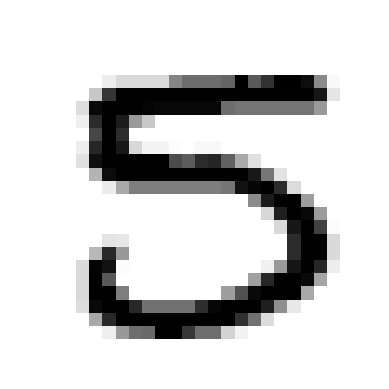

In [17]:
plot_digit(X_train.iloc[11].values)

# How does  above array representing X_train[11] which is image of 5?

The array representing X_train[11] corresponds to an image because each value in the array represents the intensity of a pixel in a 28 × 28 grayscale image. The array contains 784 values, which are reshaped into a 28 × 28 matrix to reconstruct the image. Each value indicates the brightness of a pixel, where lower values represent darker pixels and higher values represent lighter pixels. When visualized using imshow(), these pixel intensities form the handwritten digit, which in this case is “5.”

In [18]:
# Predict using the model
pred = sgd_clf.predict([X_train.iloc[11]])
pred[0]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


np.True_

# Use Cross Validation Technique

In [19]:
from sklearn.model_selection import cross_val_score

# Fit the model with CS=3 and evaluate its performance using "Accuracy". What do you expect to see?
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.91230514, 0.93930466, 0.95912354])

# !!!!!! Wait a minute!!!!!!
## What just happened? In your first attempts, you have a model with 95% accuract? Do you trust your model?

Although the model achieved approximately 95% accuracy, this result is misleading and should not be fully trusted. The dataset was transformed into a binary classification problem to detect the digit “5,” which represents only about 10% of the data. Due to this class imbalance, a model can achieve high accuracy simply by predicting the majority class (not 5) most of the time. This is confirmed by the baseline model that never predicts “5” but still achieves around 90% accuracy. Therefore, accuracy is not an appropriate metric in this case, and evaluation should instead rely on precision, recall, and F1-score to better assess model performance.

In [20]:
#Above cell mimics below logic. As you see the results are the same. This cell is just for your self-study. Using previous cell is good enough in practice
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train.iloc[train_index]
    y_train_folds = (y_train_5.iloc[train_index])
    X_test_fold = X_train.iloc[test_index]
    y_test_fold = (y_train_5.iloc[test_index])

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


0.9563400653559758


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


0.9442331386939519
0.9573556198435659


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


#Question: What is StratifiedKFold for? Can you search for it online and type your answer in Chat?

StratifiedKFold is a cross-validation technique used to split a dataset into multiple folds while preserving the proportion of each class in every fold. This is especially important in classification problems with imbalanced data, as it ensures that each fold is a representative sample of the overall dataset. By maintaining class distribution, StratifiedKFold provides a more reliable and unbiased evaluation of model performance compared to standard K-Fold.


In [21]:
#BaseEstimator is when there is no model!
from sklearn.base import BaseEstimator
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

In [25]:

never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.91107302, 0.90914448, 0.90978249])

## As you see accuracy of base model is 90%!

Can you explain it?

The base model achieves approximately 90% accuracy because the dataset is highly imbalanced. Only about 10% of the samples correspond to the digit “5,” while 90% belong to other digits. The Never5Classifier always predicts “not 5,” which means it correctly classifies all non-5 digits. As a result, it achieves high accuracy despite failing to identify any actual instances of the digit “5.” This demonstrates that accuracy alone is not a reliable metric for evaluating models on imbalanced datasets.

In [22]:
# Look at number of times 5 is repeated in the dataset!
import numpy as np

np.unique(y_train_5, return_counts=True)

# As expected, 5 is repeated only 10% of the times. So, even if we never detect it, stil we will have 90% accuracy!


(array([False,  True]), array([50960,  5040]))

In [26]:
np.unique(never_5_clf.predict(X_train), return_counts = True)

(array([False]), array([56000]))

In [24]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=10)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

#A food for your thought:

#### Look at below evaluation results (confusion matrix, Precision and Recall values) and record them in your book. Then change the value of cv in above cell. Either increase or decrese cv and calculate precision and recall again. What do you observe?

# Can you explain it?

By changing the value of cv in cross-validation, the confusion matrix, precision, and recall values vary slightly because the dataset is split differently each time. Lower values of cv result in fewer splits and higher variability, while higher values provide more stable and reliable performance estimates. This occurs because each data point is evaluated more thoroughly across multiple folds, leading to a more accurate assessment of the model.

#Confusion Matrix format:
[[TN  FP]
[FN  TP]]

- TN → correctly predicted NOT 5
- FP → predicted 5 but wrong
- FN → missed 5
- TP → correctly predicted 5


In [27]:
# Generate predictions using cross-validation

from sklearn.model_selection import cross_val_predict

# Change cv here (try 3, 5, 10)
cv_value = 10

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=cv_value)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

In [28]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[50381   579]
 [ 1588  3452]]


In [29]:
# Precision and Recall

from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_train_5, y_train_pred)
recall = recall_score(y_train_5, y_train_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.8563631853138179
Recall: 0.6849206349206349


In [30]:
# Label the matrix

import pandas as pd

cm_df = pd.DataFrame(cm,
                     index=["Actual Not 5", "Actual 5"],
                     columns=["Predicted Not 5", "Predicted 5"])

print(cm_df)

              Predicted Not 5  Predicted 5
Actual Not 5            50381          579
Actual 5                 1588         3452


In [41]:
# CV Values

cv_value = 3   # try 3, then 5, then 10

# Too good to be true !!! Hard to trust the model!

In [31]:
y_train_perfect_predictions = y_train_5

# Precision of our SGD model!

In [32]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred)

#2995/(2995+291)

0.8563631853138179

#  Recall of our SGD model

In [33]:
recall_score(y_train_5, y_train_pred)

#2995/(2995+2045)

0.6849206349206349

# F1 score of our model

In [34]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

# As you see, F1 score penalizes 91% compared to 59% recall

0.7611068239444383

#What is best Precision Recall Ratio?

In [35]:
#
y_scores = sgd_clf.decision_function([some_digit])
y_scores

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([-713019.39065759])

In [37]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)

In [38]:
y_some_digit_pred

array([False])

In [39]:
threshold = 200000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [40]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [41]:
y_scores_ = sgd_clf.decision_function(X_train)
y_scores_

array([   5963.20358648, -363746.26157173,   67327.05185641, ...,
        -79483.86206143, -247685.13679906, -433566.97267746])

Note: there was an [issue](https://github.com/scikit-learn/scikit-learn/issues/9589) in Scikit-Learn 0.19.0 (fixed in 0.19.1) where the result of `cross_val_predict()` was incorrect in the binary classification case when using `method="decision_function"`, as in the code above. The resulting array had an extra first dimension full of 0s. Just in case you are using 0.19.0, we need to add this small hack to work around this issue:

In [42]:
y_scores.shape

(56000,)

In [43]:
# hack to work around issue #9589 in Scikit-Learn 0.19.0
if y_scores.ndim == 2:
    y_scores = y_scores[:, 1]

# Plot Precision/Recall Curve

- Where is the best balance?
- Where does precision drop fast?
- Where does recall increase?


Based on the precision-recall curve, the best balance between precision and recall occurs at a threshold of approximately 50,000 to 100,000, where both values are relatively high and close to each other. Precision is low at very low threshold values because the model predicts many positive cases, resulting in a high number of false positives. As the threshold increases, precision improves while recall decreases. Recall is highest at low thresholds, where the model captures nearly all actual positive cases. This demonstrates the tradeoff between precision and recall, where increasing one often leads to a decrease in the other.

In [72]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

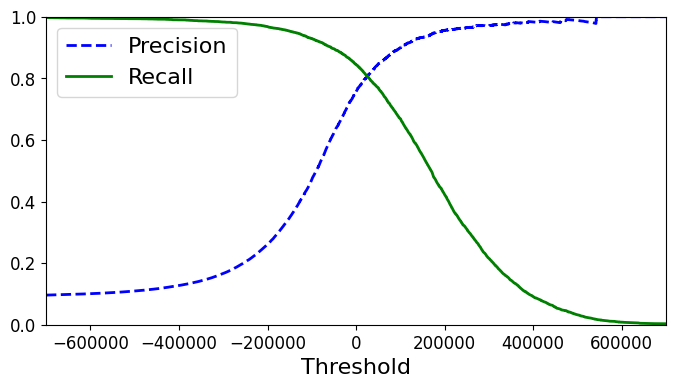

In [73]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.xlabel("Threshold", fontsize=16)
    plt.legend(loc="upper left", fontsize=16)
    plt.ylim([0, 1])

plt.figure(figsize=(8, 4))
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.xlim([-700000, 700000])
#save_fig("precision_recall_vs_threshold_plot")
plt.show()

In [46]:
(y_train_pred == (y_scores > 0)).all()

np.False_

In [47]:
y_train_pred_90 = (y_scores > 70000)

In [48]:
precision_score(y_train_5, y_train_pred_90)

0.7105596812171708

In [49]:
recall_score(y_train_5, y_train_pred_90)

0.7783730158730159

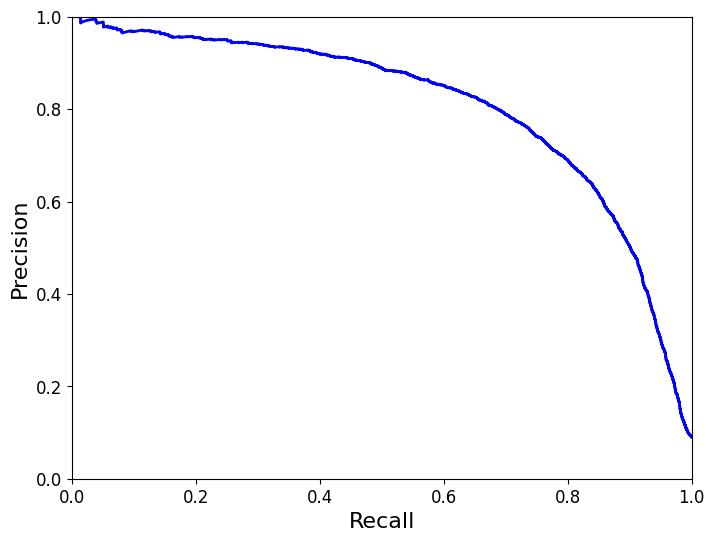

In [50]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])

plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precisions, recalls)
#save_fig("precision_vs_recall_plot")
plt.show()

# ROC curves

In [51]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

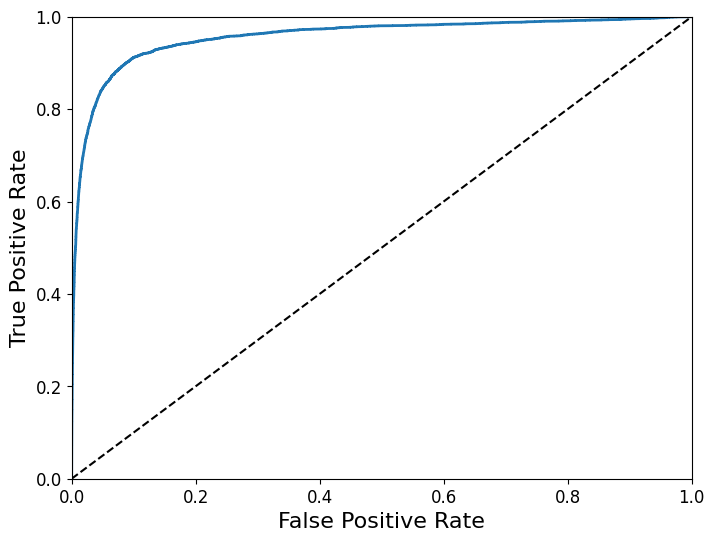

In [52]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)

plt.figure(figsize=(8, 6))
plot_roc_curve(fpr, tpr)
#save_fig("roc_curve_plot")
plt.show()

The ROC curve demonstrates that the model performs very well, as the curve is close to the top-left corner and significantly above the diagonal baseline representing a random classifier. This indicates that the model achieves a high true positive rate while maintaining a low false positive rate across different thresholds. The area under the curve (AUC) appears to be close to 1, suggesting excellent classification performance. Overall, the model is highly effective at distinguishing between the digit “5” and non-“5” cases.

In [53]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

np.float64(0.9568028184259051)

**Note**: we set `n_estimators=10` to avoid a warning about the fact that its default value will be set to 100 in Scikit-Learn 0.22.

In [54]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(n_estimators=10, random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

In [55]:
y_scores_forest = y_probas_forest[:, 1] # score = proba of positive class
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5,y_scores_forest)

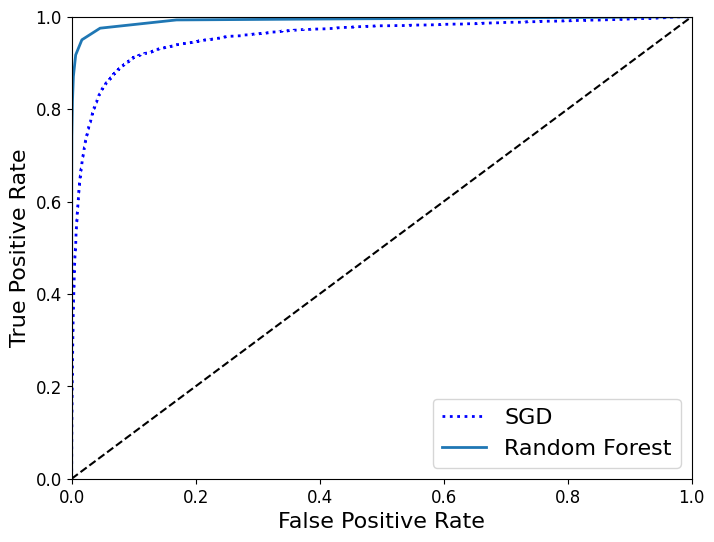

In [56]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, "b:", linewidth=2, label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right", fontsize=16)
#save_fig("roc_curve_comparison_plot")
plt.show()

Based on the ROC curve comparison, the Random Forest model outperforms the SGD classifier. The Random Forest curve is consistently closer to the top-left corner and lies above the SGD curve, indicating a higher true positive rate for the same false positive rate. This suggests that the Random Forest model has a higher AUC and better overall classification performance. While SGD is efficient and suitable for large datasets, Random Forest provides more accurate predictions in this case due to its ability to capture more complex patterns in the data.

In [57]:
roc_auc_score(y_train_5, y_scores_forest)

np.float64(0.992434493829583)

In [58]:
y_train_pred_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3)
precision_score(y_train_5, y_train_pred_forest)

0.984225621414914

In [59]:
recall_score(y_train_5, y_train_pred_forest)

0.817063492063492

This project demonstrated that accuracy is not always a reliable metric, especially in imbalanced datasets. By using precision, recall, F1-score, and ROC analysis, we gained a deeper understanding of model performance. The Random Forest model outperformed SGD, showing better classification capability. Overall, the project highlights the importance of proper evaluation and model selection in machine learning.